In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

from qldpc import codes
from qldpc.objects import Pauli
import networkx as nx
import matplotlib.pyplot as plt
import sinter

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.GBCode import GBCode
from src.QECCode import TestCode
from src.decoders import BPOSD

In [ ]:
hwp = device.default_hwp

code_bb = GBCode(12, 6, ([3], [1, 2]), ([1, 2], [3]))

buffer = 3
xmax,ymax = 0,0
data_coords = dict()
for i in code_bb.data_indices:
    x,y = code_bb.qubit_coords[i]
    data_coords[i] = (x+buffer, y+buffer)
    xmax = max(xmax, x)
    ymax = max(ymax, y)

dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)

sched_bb = dev.compile_QEC_schedule(
    code_bb,
    data_coords,
    [],
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=True,
    optimize_ancilla_start=True,
    separate_X_Z=True
)

ds = [3,5,7,9,11]
codes_surf = []
schedules_surf = []
for d in ds:
    codes_surf.append(RotatedSurfaceCode(d))
    schedules_surf.append(codes_surf[-1].get_schedule(hwp, basis='Z', refocus_shuttling_noise=True))

ps = np.geomspace(1e-2, 1e-4, 7)
tasks = []
for p in ps:
    t2 = 1e-6/p
    error_params = device.error_params(p=p, T2=t2, p_sh=p/100)
    tasks.append(sinter.Task(
        circuit=sched_bb.to_stim_circuit(code_bb, 'Z', error_params),
        decoder='bposd',
        json_metadata={'code':'[[144,12,12]]', 'p':p}
    ))
    for d,code,sched in zip(ds, codes_surf, schedules_surf):
        tasks.append(sinter.Task(
            circuit=sched.to_stim_circuit(code, 'Z', error_params),
            decoder='pymatching',
            json_metadata={'code':f'[[{d**2},1,{d}]]', 'p':p},
        ))

/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Optimizing 72 ancilla schedules........................................................................
Optimizing 72 ancilla schedules........................................................................


In [ ]:
custom_decoders = {'bposd': BPOSD(
    max_iter=1000,
    bp_method='minimum_sum',
    ms_scaling_factor=0.625,
    osd_method='OSD_CS',
    osd_order=10,
)}

stats = sinter.collect(num_workers=30, tasks=tasks, max_shots=10**6, max_errors=500, custom_decoders=custom_decoders, print_progress=True)

Starting 30 workers...
42 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                              
        1      bposd   ?    1000000         500 code=[[144,12,12]],p=0.01                  
        1 pymatching   ?    1000000         500 code=[[9,1,3]],p=0.01                      
        1 pymatching   ?    1000000         500 code=[[25,1,5]],p=0.01                     
        1 pymatching   ?    1000000         500 code=[[49,1,7]],p=0.01                     
        1 pymatching   ?    1000000         500 code=[[81,1,9]],p=0.01                     
        1 pymatching   ?    1000000         500 code=[[121,1,11]],p=0.01                   
        1      bposd   ?    1000000         500 code=[[144,12,12]],p=0.004641588833612777  
        1 pymatching   ?    1000000         500 code=[[9,1,3]],p=0.004641588833612777      
        1 pymatching   ?    1000000         500 code=[[25,1,5]],p=0.004641588833612777     
        1 pymatching   ?    1000000       

In [ ]:
ps_by_code = {}
stats_by_code = {}
for stat in stats:
    code = stat.json_metadata['code']
    n = int(code.split(',')[0][2:])
    k = int(code.split())

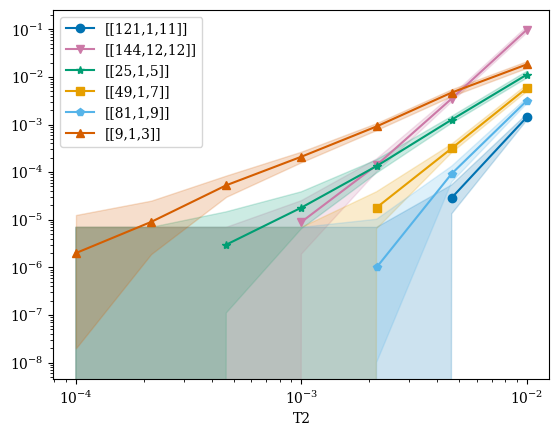

In [7]:
fig,ax = plt.subplots()
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['code'],
)
plt.loglog()
plt.xlabel('T2')
plt.ylabel('')
plt.legend()
plt.show()